# PS-MNIST Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the PS-MNIST dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Use **test set metrics** for final evaluation
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [4]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

compare_folder = Path("figs")
compare_folder.mkdir(exist_ok=True)

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [2]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "psmnist"

print("="*60)
print("LOADING PS-MNIST EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING PS-MNIST EXPERIMENT RESULTS

Loading S4 @ 10%: psmnist_s4_task_frac_10
Loading S4 @ 25%: psmnist_s4_task_frac_25
Loading S4 @ 50%: psmnist_s4_task_frac_50
Loading S4 @ 100%: psmnist_s4_task_equal_params
Loading LMU @ 10%: psmnist_lmu_task_frac_10
Loading LMU @ 25%: psmnist_lmu_task_frac_25
Loading LMU @ 50%: psmnist_lmu_task_frac_50
Loading LMU @ 100%: psmnist_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## Results Summary Table


In [3]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

print()
print(test_comparison_df)



BEST MODEL PER DATA FRACTION

10% data: LMU (Accuracy: 91.54%)

25% data: LMU (Accuracy: 94.14%)

50% data: LMU (Accuracy: 94.75%)

100% data: S4 (Accuracy: 97.05%)

  model  data_pct  accuracy   loss  num_samples
0   LMU        10    0.9154 0.2986        10000
1   LMU        25    0.9414 0.2142        10000
2   LMU        50    0.9475 0.1811        10000
3   LMU       100    0.9624 0.1499        10000
4    S4        10    0.7411 0.7622        10000
5    S4        25    0.8758 0.4087        10000
6    S4        50    0.9200 0.2769        10000
7    S4       100    0.9705 0.1319        10000


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


Plot saved to: figs/test_data_efficiency.png


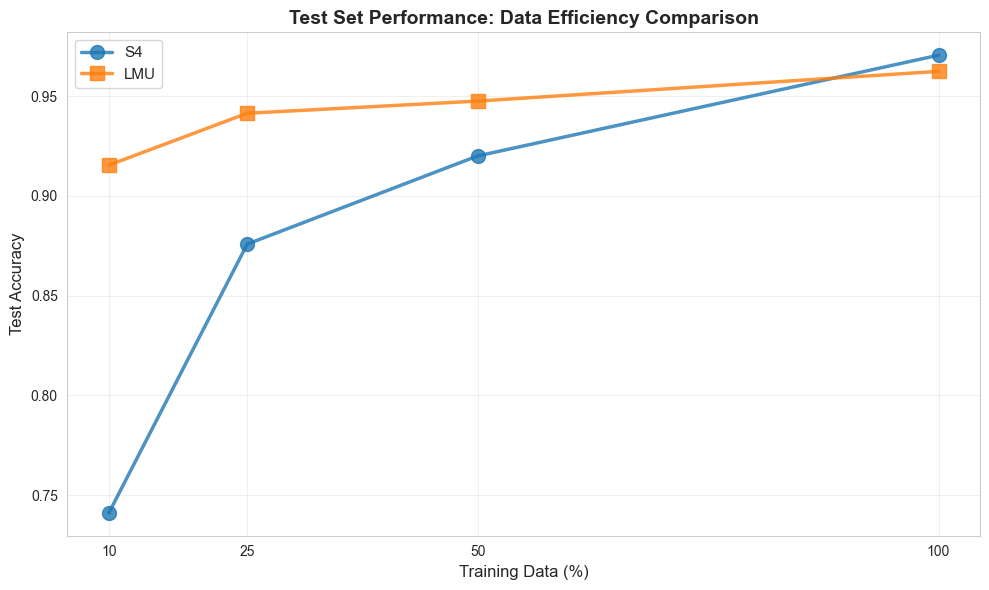

In [5]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_data_efficiency.png')
)

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


Plot saved to: figs/test_loss_comparison.png


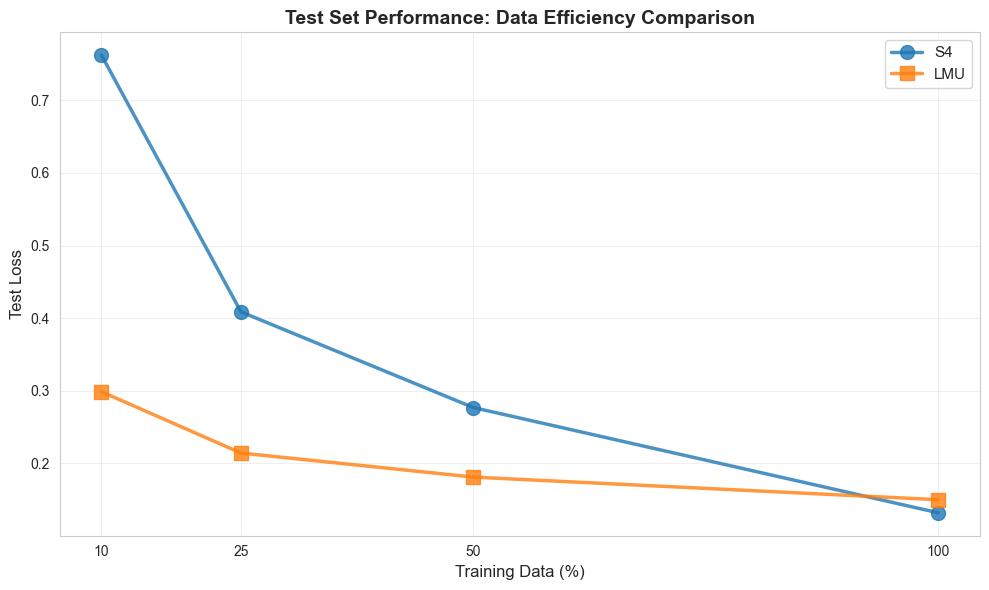

In [6]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss',
    save_path=str(compare_folder / 'test_loss_comparison.png')
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


Plot saved to: figs/test_accuracy_comparison.png


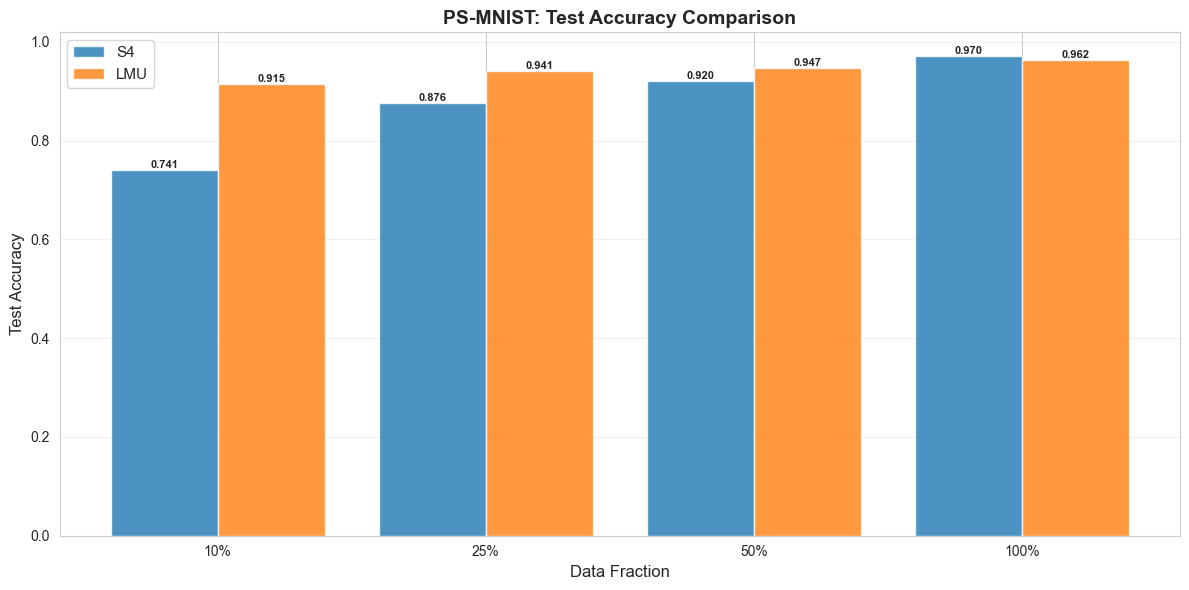

In [7]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='PS-MNIST: Test Accuracy Comparison',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_accuracy_comparison.png')
)

### Heatmap Visualization

Visual comparison of test accuracy across models and data fractions.


Plot saved to: figs/test_performance_heatmap.png


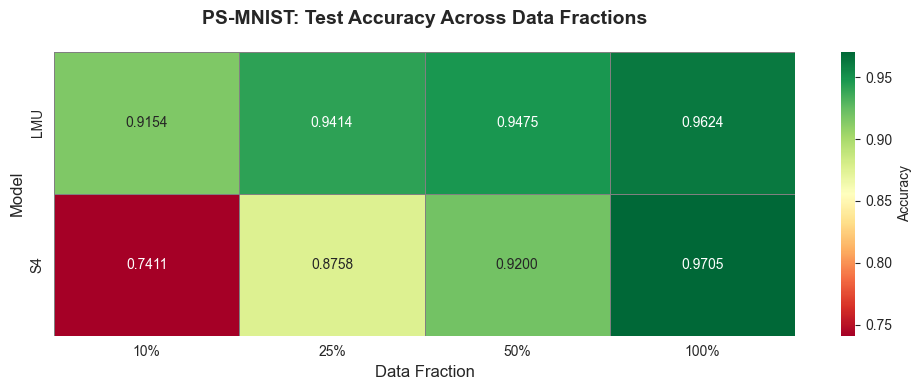

In [8]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='accuracy',
    title='PS-MNIST: Test Accuracy Across Data Fractions',
    annot_format='.4f',
    save_path=str(compare_folder / 'test_performance_heatmap.png')
)